# Jaba Basics

This Python Jupyter Notebook will guide you through the very basics of using `jaba` in your code. I expect you to know how basic python works, but you can run through the `python_tutorial.ipynb` file if not, which should guide you through the basics. 

If you are not used to using Python in a Jupyter Notebook (e.g. normally run python in `.py` files), all you need to know is that when you run a cell (shift-tab) it runs python on whatever you put in it in sequential order as usual, but *it retains the memory state across the whole notebook.* That is, if you set a variable/function/class in one cell and run it, then it is thereafter accessible from any cell, no matter the order it is in, until you restart the kernel (so, what matters instead is the order you run cells in).

In [1]:
# You can access the jaba code package by importing jaba.
# Press shift-enter to run the cell. 
# If it works, congrats! You are all set up and you can now use "jaba" to refer to the package and access its submodules, classes, and functions.
# If instead it gives you an import error, you likely do not have the package installed in your current environment. 
# Please read the README for installation instructions or contact Jaeden Bardati (jbardati@caltech.edu) if you have questions about the code.
import jaba

In [ ]:
# You can also load specific commonly-used submodules (such as units and constants) and give them a name to refer to them as follows.
# But these can always be accessed as jaba.units and jaba.constants, so this is just for convenience if you will be using them a lot in your code.
# Personally, I often do this with units, constants, and visual since I use them a lot. Namely, 
import jaba.units as u
import jaba.constants as c
import jaba.visual as jv

### Simulation Snapshots

##### Loading basics

In [3]:
# You can load a snapshot by providing a filepath to the snapshot file. For example,
snap = jaba.load("/Users/jaedenbardati/Documents/Code/Research/Caltech/FIF_Research/skirt_output/snapshot_000.hdf5")

In [4]:
# From here, there are a lot of things you can do.
# The first thing you might want to do is look at the snapshot's datasets and attributes.
snap.available_datasets

{('PartType0', 'Acceleration'),
 ('PartType0', 'Coordinates'),
 ('PartType0', 'Density'),
 ('PartType0', 'DensityGradient'),
 ('PartType0', 'DustToGasRatio_Local'),
 ('PartType0', 'Dust_Temperature'),
 ('PartType0', 'EddingtonTensor'),
 ('PartType0', 'ElectronAbundance'),
 ('PartType0', 'HII'),
 ('PartType0', 'HydroAcceleration'),
 ('PartType0', 'IRBand_Radiation_Temperature'),
 ('PartType0', 'InternalEnergy'),
 ('PartType0', 'MagneticField'),
 ('PartType0', 'Masses'),
 ('PartType0', 'Metallicity'),
 ('PartType0', 'MolecularMassFraction'),
 ('PartType0', 'NeutralHydrogenAbundance'),
 ('PartType0', 'ParticleChildIDsNumber'),
 ('PartType0', 'ParticleIDGenerationNumber'),
 ('PartType0', 'ParticleIDs'),
 ('PartType0', 'PhotonEnergy'),
 ('PartType0', 'PhotonFluxDensity'),
 ('PartType0', 'PhotonOpacity'),
 ('PartType0', 'Potential'),
 ('PartType0', 'Pressure'),
 ('PartType0', 'RadiativeAcceleration'),
 ('PartType0', 'SmoothingLength'),
 ('PartType0', 'SoundSpeed'),
 ('PartType0', 'StarFormat

In [5]:
# You can then call any of these datasets by feeding them as a key to the snapshot.
# If the loader inferred a unit system, the returned arrays will usually be astropy quantity arrays, 
# so you can get the units with ".unit" or the values-only with ".value"  or convert units with ".to(unit)"
snap[(('PartType0', 'Density'))]

<Quantity [3.53192601e+02, 4.83598714e+02, 4.17133127e+02, ...,
           4.78844318e+05, 5.09655801e+05, 3.03383977e+05] M_p / cm3>

In [6]:
# Certain commonly-used datasets have their own properties for easier access.
# Namely, position (.pos), velocity (.vel), density (.dens), mass (.mass), smoothing length (.smooth) datasets.
# They will error if they do not exist in the given snapshot
snap.dens0          # loads the density for the first particle type

<Quantity [3.53192601e+02, 4.83598714e+02, 4.17133127e+02, ...,
           4.78844318e+05, 5.09655801e+05, 3.03383977e+05] M_p / cm3>

In [7]:
# Instead of loaded all datasets at once, the snapshot will only load datasets when they are called on for the first time.
# From then on, it will be cached in memory for quick access.
# To view all currently loaded datasets, use
snap.loaded_datasets

{('PartType0', 'Density')}

##### Coordinate Transformation

There is basic transformation functionality included in the snapshot object including translation and rotation. Transformation parameters are given relative to the current transformation state (i.e. `snap.pos0` is in). 

By default these transformations will be applied to all known vector/tensor-like datasets (e.g. position, velocity, acceleration are vectors, but metallicity is not despite having being a list of values per particle/cell). The transformation laws are specified in `_CONVENIENCE_ATTRS`. You may have your own vectors/tensor-like objects which are not recognized by the loader that you need to add to this list to make sure they transform properly. 

In [8]:
# To center the position on a specific point
snap.center_pos([1, 2, 3]*u.pc)

# To center the velocity on a specific point
snap.center_vel([3, 2, 1]*u.km/u.s)

# To rotate by a specific angle (in degrees) around a given axis
snap.rotate_x(45)

# To align a certain axis to a given direction vector
snap.align_z([1.2, 0.5, -0.3])

# To shift by a specific amount in a given direction
snap.shift_z(10*u.pc)

# To boost by a specific velocity in a given direction
snap.boost_vx(10*u.km/u.s)

# And more (see snapshot.py for more details)

In [9]:
# You can reset the transformation to the original state with
snap.reset_transform()

# You can center around a specific particle type with
snap.center_on(3, verbose=True)

# You can also rotate to a faceon or edgeon view of a given particle type with
snap.faceon(radius=1*u.pc)

Centering on particle of type 3 at index 0 with position [-0.2368953  -0.02209853  0.08310537] pc and velocity [-29.17259634 -10.41894853  14.27237839] km / s...
Transforming loaded dataset pos3 like a vector...
Transforming loaded dataset vel3 like a vector...
Other datasets will be transformed on the fly when loaded.


##### Visualization

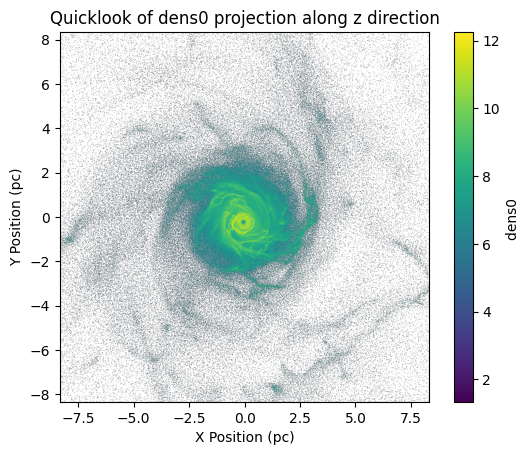

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Quicklook of dens0 projection along z direction'}, xlabel='X Position (pc)', ylabel='Y Position (pc)'>)

In [19]:
# you can quickly visualize a projection of the snapshot quantity you want with
snap.quicklook(qty='dens0')

In [ ]:
# a more accurate projection plot can be made with
snap.projection_plot(qty='dens0', width=10*u.pc)

In [ ]:
# you can also make a slice plots
snap.slice_plot(qty='dens0', width=10*u.pc)

##### Conversion to other analysis codes

I have a couple very basic conversion functions if you have something you need in another analysis code like `pynbody` or `yt`. Use with caution and check everything. You will likely need to adapt the code to suite your specific use cases.

In [11]:
# Convert to pynbody snap
s = snap.to_pynbody()

# You can also convert units to/from pynbody units with
import pynbody
u.to_pynbody(u.kpc), u.from_pynbody(pynbody.units.kpc)

(Unit("kpc"), Unit("kpc"))

##### Applications

There are many package application functions included in the `apps` submodule. This is keep growing as I use `jaba` for more and more things. While there is no guarantee that *any* of this code will work, this section of the code is the most work-in-progess, specific to certain simulations, and requires you to really know what you are doing. You should thoroughly read all application code you plan to use before running it.

In [12]:
# To import this submodule call
import jaba.apps as apps

# You can then call any of the apps as needed, for example to calculate an estimate for the BLR H-alpha emission in the snapshot, you can run
apps.blr.get_Halpha_emissivity_gizmo(snap)

/Users/jaedenbardati/MyPythonPackages/jaba/jabapy/snapshot.py:591: UserWarning: Dataset Metallicity for particle type PartType0 does not have a defined unit or transformation behavior. Please update Basic_GIZMO_Snapshot._CONVENIENCE_ATTRS to include it if necessary.
  warnings.warn('Dataset {} for particle type {} does not have a defined unit or transformation behavior. Please update Basic_GIZMO_Snapshot._CONVENIENCE_ATTRS to include it if necessary.'.format(dataset_name, particle_type))
/Users/jaedenbardati/MyPythonPackages/jaba/jabapy/snapshot.py:591: UserWarning: Dataset ElectronAbundance for particle type PartType0 does not have a defined unit or transformation behavior. Please update Basic_GIZMO_Snapshot._CONVENIENCE_ATTRS to include it if necessary.
  warnings.warn('Dataset {} for particle type {} does not have a defined unit or transformation behavior. Please update Basic_GIZMO_Snapshot._CONVENIENCE_ATTRS to include it if necessary.'.format(dataset_name, particle_type))


array([0., 0., 0., ..., 0., 0., 0.], shape=(1934547,))